In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,confusion_matrix)
from sklearn.preprocessing import LabelEncoder

In [6]:
df = pd.read_csv("C:\Project1\csv\streaming_transactions.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\malde\AppData\Local\Temp\ipykernel_22384\2643136053.py:1: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("C:\Project1\csv\streaming_transactions.csv")


,transaction_id,user_id,user_type,amount,merchant_category,merchant,location,device_type,device_id,timestamp,...,is_night_transaction,is_foreign_transaction,amount_balance_ratio,is_high_amount,device_change,previous_transaction_time,transaction_gap_seconds,rapid_transaction,transactions_last_5min,time_since_last_transaction
0,TXN_0cc94698d7,USER_0042,high_net_worth,186.05,restaurants,KFC,Pune,android,DEVICE_60b362e8,2026-05-19 00:32:23.589665,...,1,0,0.000263,0,1,2026-05-20 04:26:22.575997,-100438.986332,1,3,NaN
1,TXN_c6a6ac52cc,USER_0027,high_net_worth,345.51,fashion,Lifestyle,Chennai,web,DEVICE_efc87a52,2026-05-19 00:32:23.591101,...,1,0,0.000079,0,1,2026-05-20 17:55:53.576491,-149009.985390,1,3,NaN
2,TXN_40a6a9ba04,USER_0039,salaried,419.51,restaurants,McDonalds,Chennai,ios,DEVICE_0a8adf9d,2026-05-19 00:32:23.592630,...,1,0,0.023209,0,1,2026-05-21 00:53:25.575805,-174061.983175,1,2,NaN
3,TXN_fb7d71a603,USER_0028,business,4997.32,restaurants,McDonalds,Ahmedabad,android,DEVICE_9720bebf,2026-05-19 00:32:23.626554,...,1,0,0.023954,0,1,2026-05-22 00:02:52.576243,-257428.949689,1,3,NaN
4,TXN_0734773ee7,USER_0047,business,412.22,grocery,BigBasket,Kolkata,ios,DEVICE_9eae3536,2026-05-19 00:32:23.629069,...,1,0,0.039158,0,1,2026-05-21 17:28:53.597520,-233789.968451,1,2,NaN


In [7]:
print(df.columns.tolist())

['transaction_id', 'user_id', 'user_type', 'amount', 'merchant_category', 'merchant', 'location', 'device_type', 'device_id', 'timestamp', 'old_balance', 'new_balance', 'remaining_balance', 'account_age_days', 'daily_transaction_count', 'fraud_label', 'fraud_type', 'transaction_hour', 'is_night_transaction', 'is_foreign_transaction', 'amount_balance_ratio', 'is_high_amount', 'device_change', 'previous_transaction_time', 'transaction_gap_seconds', 'rapid_transaction', 'transactions_last_5min', 'time_since_last_transaction']


In [8]:
df.shape

(4848, 28)

In [9]:
X = df[[

    "transaction_gap_seconds",

    "transactions_last_5min",

    "device_change",

    "amount",

    "amount_balance_ratio",

    "transaction_hour",

    "user_type",

    "merchant_category",

    "merchant",

    "location",

    "device_type",

    "is_high_amount"
]]
y = df["fraud_label"]

In [10]:
X.shape,y.shape

((4848, 12), (4848,))

In [11]:
df = df.fillna(0)

df.isnull().sum()

transaction_id                 0
user_id                        0
user_type                      0
amount                         0
merchant_category              0
merchant                       0
location                       0
device_type                    0
device_id                      0
timestamp                      0
old_balance                    0
new_balance                    0
remaining_balance              0
account_age_days               0
daily_transaction_count        0
fraud_label                    0
fraud_type                     0
transaction_hour               0
is_night_transaction           0
is_foreign_transaction         0
amount_balance_ratio           0
is_high_amount                 0
device_change                  0
previous_transaction_time      0
transaction_gap_seconds        0
rapid_transaction              0
transactions_last_5min         0
time_since_last_transaction    0
dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder


object_columns = X.select_dtypes(
    include=["object"]
).columns


encoders = {}


for column in object_columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(
        X[column].astype(str)
    )

    encoders[column] = encoder


print(X.dtypes)

transaction_gap_seconds    float64
transactions_last_5min       int64
device_change                int64
amount                     float64
amount_balance_ratio       float64
transaction_hour             int64
user_type                    int64
merchant_category            int64
merchant                     int64
location                     int64
device_type                  int64
is_high_amount               int64
dtype: object


In [13]:
X_train, X_test, y_train, y_test = (

    train_test_split(

        X,
        y,

        test_size=0.2,

        random_state=42,

        stratify=y
    )
)

print(X_train.shape)

print(X_test.shape)

(3878, 12)
(970, 12)


In [14]:
model = XGBClassifier(

    n_estimators=200,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=10,

    random_state=42
)

In [15]:
print(X.dtypes)

transaction_gap_seconds    float64
transactions_last_5min       int64
device_change                int64
amount                     float64
amount_balance_ratio       float64
transaction_hour             int64
user_type                    int64
merchant_category            int64
merchant                     int64
location                     int64
device_type                  int64
is_high_amount               int64
dtype: object


In [16]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
y_pred = model.predict(X_test)

In [18]:
print("\nCLASSIFICATION REPORT\n")

print(

    classification_report(

        y_test,

        y_pred
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       928
           1       0.95      0.88      0.91        42

    accuracy                           0.99       970
   macro avg       0.97      0.94      0.95       970
weighted avg       0.99      0.99      0.99       970



In [19]:
print("\nCONFUSION MATRIX\n")

print(

    confusion_matrix(

        y_test,

        y_pred
    )
)


CONFUSION MATRIX

[[926   2]
 [  5  37]]


In [20]:
importance_df = pd.DataFrame({

    "feature": X.columns,

    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(

    by="importance",

    ascending=False
)

importance_df.head(15)

,feature,importance
0,transaction_gap_seconds,0.337239
2,device_change,0.276571
3,amount,0.099253
1,transactions_last_5min,0.082576
11,is_high_amount,0.067822
4,amount_balance_ratio,0.030744
6,user_type,0.027422
9,location,0.026235
5,transaction_hour,0.017114
8,merchant,0.014525


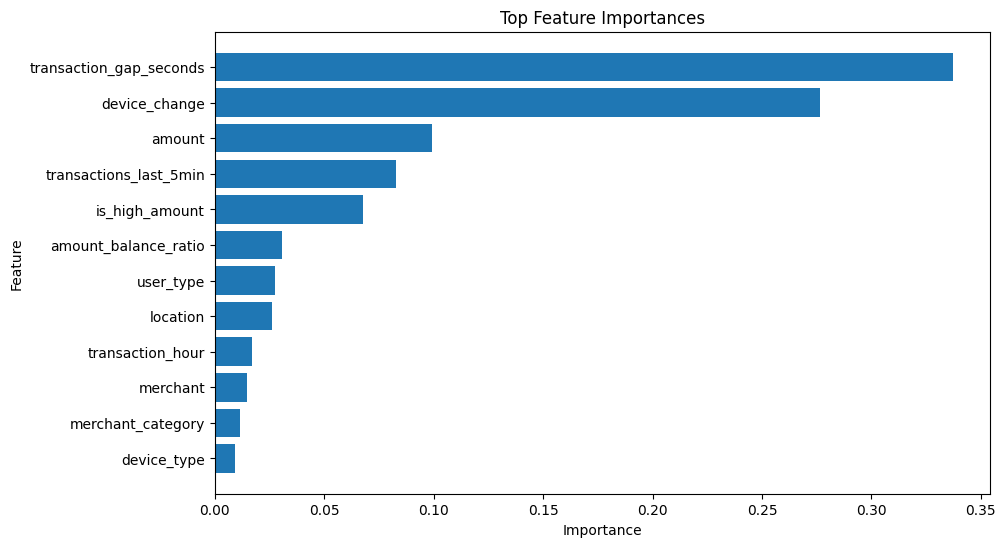

In [21]:
import matplotlib.pyplot as plt


top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(

    top_features["feature"],

    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top Feature Importances")

plt.show()

In [22]:
model = XGBClassifier(

    n_estimators=200,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=10,

    random_state=42
)
model.fit(X_train, y_train)
y_proba = model.predict_proba(
    X_test
)[:,1]

In [24]:
from sklearn.metrics import (
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

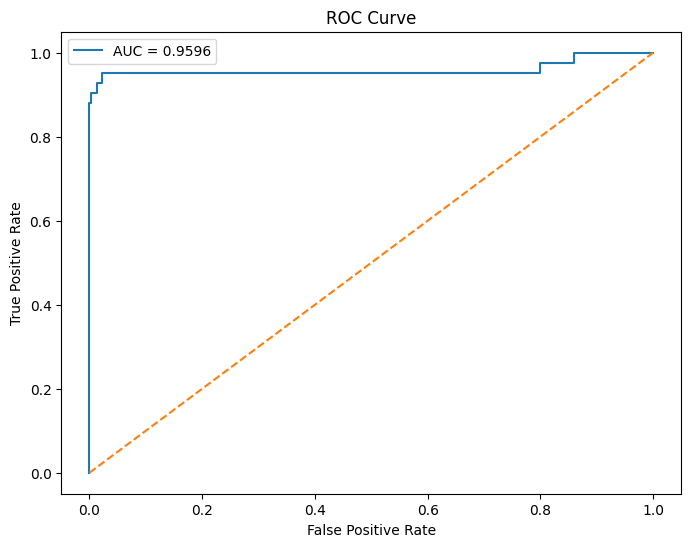

In [25]:
fpr, tpr, thresholds = roc_curve(

    y_test,

    y_proba
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

In [26]:
from sklearn.metrics import (
    precision_recall_curve
)

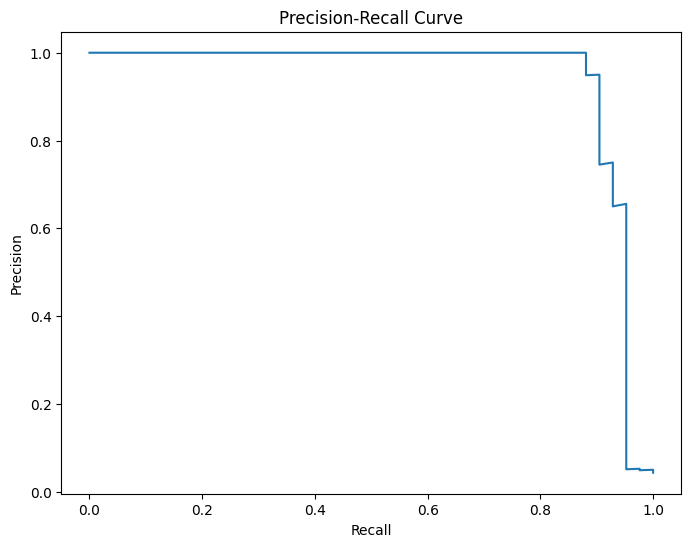

In [27]:
precision, recall, pr_thresholds = (

    precision_recall_curve(

        y_test,

        y_proba
    )
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.show()

In [62]:
from sklearn.metrics import (
    classification_report
)

threshold = 0.6

In [63]:
y_pred_custom = (

    y_proba >= threshold
).astype(int)

In [64]:
print(

    classification_report(

        y_test,

        y_pred_custom
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       928
           1       1.00      0.86      0.92        42

    accuracy                           0.99       970
   macro avg       1.00      0.93      0.96       970
weighted avg       0.99      0.99      0.99       970

